# Evaluate a trained LLM for the agent

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
current_dir = Path().resolve()
sys.path.append(str(current_dir.parent))
import bibleAssistant.evaluation as evaluation

In [38]:
import os
import json
import pandas as pd
import numpy as np
import sklearn, sklearn.metrics
import matplotlib, matplotlib.pyplot as plt
import ollama

In [4]:
from IPython.display import HTML

In [5]:
dev_folder = os.path.abspath("../data/dev")
print(f"What are the possible data files (in {dev_folder}):")
print(os.listdir(dev_folder))

print("-"*40)
print("What output model folders we already have:")
print(os.listdir("../models"))

print("-"*40)
print("Which models are already locally served in ollama:")
print([item.model for item in ollama.list().models])

What are the possible data files (in c:\Users\Yonatan\Documents\coding_projects\bible-text-analysis\data\dev):
['images', 'lookup_verse.3.test.jsonl', 'lookup_verse.3.train.jsonl', 'two_tools.1.test.jsonl', 'two_tools.1.train.jsonl']
----------------------------------------
What output model folders we already have:
['gemma3-2tools1', 'gemma3-lora-8', 'gemma3-lora-9']
----------------------------------------
Which models are already locally served in ollama:
['gemma3:1b-2t1-426', 'gemma3:1b-2t1-250', 'gemma3:1b-ft9-650', 'gemma3:1b-ft9-350', 'gemma3:1b-ft3-50', 'gemma3:1b-ft3-200', 'gemma3:1b-ft3', 'gemma3:1b-ft2', 'gemma3:1b-ft1', 'google/gemma-3-1b-it-ft1:latest', 'gemma3:4b', 'llama3.2:3b', 'llama3.2:1b', 'gemma3:1b', 'mistral:latest']


In [6]:
model_name = "gemma3:1b-2t1-426"

In [53]:
def load_examples(infile):
    with open(infile, encoding='UTF-8') as f:
        examples = []
        for line in f:
            examples.append(json.loads(line))
        print(f"<== Read {len(examples)} examples from {infile}")
    return examples

In [54]:
trainset_file = os.path.join(dev_folder, "two_tools.1.train.jsonl")
testset_file = os.path.join(dev_folder, "two_tools.1.test.jsonl")
train_examples = load_examples(trainset_file)
test_examples = load_examples(testset_file)

<== Read 850 examples from c:\Users\Yonatan\Documents\coding_projects\bible-text-analysis\data\dev\two_tools.1.train.jsonl
<== Read 150 examples from c:\Users\Yonatan\Documents\coding_projects\bible-text-analysis\data\dev\two_tools.1.test.jsonl


In [8]:
train_examples[0]

{'metadata': {'scenario': 'lookup_verse_typo_book',
  'variation1': 7,
  'typo_class': 'repeated_char',
  'wrong_args': {'version': 'he.masorah',
   'book': 'jereemiah',
   'chapter_num': 8,
   'verse_num': 2},
  'right_args': {'version': 'he.masorah',
   'book': 'jeremiah',
   'chapter_num': 8,
   'verse_num': 2},
  'tool_list_in_sys_prompt': ['lookup_verse']},
 'messages': [{'role': 'system',
   'content': 'You are a research assistant for biblical texts that always responds using a JSON object with fields "tool" and "arguments".\n\nTo respond normally to the user, use:\n{"tool": "respond_to_user", "arguments":{"text": "<text to show the user>"}}\n\nTo call a tool, you need to indicate which tool to use and what arguments to send to it - use the structure:\n{"tool": "<tool_name>", "arguments":{ ... }}\n\nAfter you call a tool, you will receive a tool-response message from role "user" containing a JSON object.\nThe tool-response object always includes fields "tool_name" and "status".\

In [9]:
tested_turns = evaluation.eval_with_ref_conversation('1', train_examples[0], model_name)

In [10]:
pd.DataFrame(tested_turns)

,convo_id,convo_metadata,tested_turn_num,message_num,input_messages,reference_response,tested_response,expected_tool_name,response_tool_name,tool_name_correct,expected_tool_args,response_tool_args,args_correct,n_args_the_same,n_args_different,arg_differences,repeat_tool_call
0,1,"{'scenario': 'lookup_verse_typo_book', 'variat...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'he.masorah', 'book': 'jereemiah',...","{'version': 'he.masorah', 'book': 'jeremiah', ...",False,0.0,1.0,"{'book': ('jereemiah', 'jeremiah')}",False
1,1,"{'scenario': 'lookup_verse_typo_book', 'variat...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'he.masorah', 'book': 'jeremiah', ...","{'version': 'he.masorah', 'book': 'jereemiah',...",False,0.0,1.0,"{'book': ('jeremiah', 'jereemiah')}",False
2,1,"{'scenario': 'lookup_verse_typo_book', 'variat...",2,6,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",respond_to_user,lookup_verse,False,{'text': 'וּשְׁטָחוּם֩ לַשֶּׁ֨מֶשׁ וְלַיָּרֵ֜ח...,"{'version': 'he.masorah', 'book': 'jeremiah', ...",NaN,NaN,NaN,None,False


In [21]:
tested_turns2 = evaluation.eval_with_ref_dataset(train_examples[:100], model_name)

Convo 0. Added 3 tested LLM turns (now collected: 3)
Convo 1. Added 2 tested LLM turns (now collected: 5)
Convo 2. Added 3 tested LLM turns (now collected: 8)
Convo 3. Added 8 tested LLM turns (now collected: 16)
Convo 4. Added 3 tested LLM turns (now collected: 19)
Convo 5. Added 6 tested LLM turns (now collected: 25)
Convo 6. Added 12 tested LLM turns (now collected: 37)
Convo 7. Added 4 tested LLM turns (now collected: 41)
Convo 8. Added 2 tested LLM turns (now collected: 43)
Convo 9. Added 4 tested LLM turns (now collected: 47)
Convo 10. Added 4 tested LLM turns (now collected: 51)
Convo 11. Added 8 tested LLM turns (now collected: 59)
Convo 12. Added 12 tested LLM turns (now collected: 71)
Convo 13. Added 1 tested LLM turns (now collected: 72)
Convo 14. Added 3 tested LLM turns (now collected: 75)
Convo 15. Added 6 tested LLM turns (now collected: 81)
Convo 16. Added 4 tested LLM turns (now collected: 85)
Convo 17. Added 2 tested LLM turns (now collected: 87)
Convo 18. Added 6 tes

In [22]:
results = pd.DataFrame(tested_turns2)
results

,convo_id,convo_metadata,tested_turn_num,message_num,input_messages,reference_response,tested_response,expected_tool_name,response_tool_name,tool_name_correct,expected_tool_args,response_tool_args,args_correct,n_args_the_same,n_args_different,arg_differences,repeat_tool_call
0,0,"{'scenario': 'lookup_verse_typo_book', 'variat...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'he.masorah', 'book': 'jereemiah',...","{'version': 'he.masorah', 'book': 'jeremiah', ...",False,0.0,1.0,"{'book': ('jereemiah', 'jeremiah')}",False
1,0,"{'scenario': 'lookup_verse_typo_book', 'variat...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'he.masorah', 'book': 'jeremiah', ...","{'version': 'he.masorah', 'book': 'he.masorah'...",False,0.0,1.0,"{'book': ('jeremiah', 'he.masorah')}",False
2,0,"{'scenario': 'lookup_verse_typo_book', 'variat...",2,6,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",respond_to_user,lookup_verse,False,{'text': 'וּשְׁטָחוּם֩ לַשֶּׁ֨מֶשׁ וְלַיָּרֵ֜ח...,"{'version': 'he.masorah', 'book': 'jeremiah', ...",NaN,NaN,NaN,None,False
3,1,"{'scenario': 'lookup_verse_ok', 'variation': 1...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'en.new.jps1917', 'book': 'genesis...","{'version': 'en.new.jps1917', 'book': 'genesis...",False,0.0,1.0,"{'book': ('genesis', 'genesis 49:12')}",False
4,1,"{'scenario': 'lookup_verse_ok', 'variation': 1...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,"{'text': 'His eyes shall be red with wine, And...",{'text': '<text to show the user>'},False,0.0,1.0,"{'text': ('His eyes shall be red with wine, An...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,97,"{'scenario': 'sequence_of_user_requests', 'seq...",3,8,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,{'text': 'ותהר עוד ותלד בן ותאמר הפעם אודה את־...,{'text': '[Genesis 29:35]: את נהרג את אחינו וש...,False,0.0,1.0,{'text': ('ותהר עוד ותלד בן ותאמר הפעם אודה את...,False
386,98,"{'scenario': 'search_phrase', 'phrase_len': 1,...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""search_phrase"", ""arguments"": {""phras...","{""tool"": ""search_phrase"", ""arguments"": {""phras...",search_phrase,search_phrase,True,{'phrase': 'ונברכו'},"{'phrase': 'ונברכו', 'n_max_results': 20}",False,0.0,0.0,{},False
387,98,"{'scenario': 'search_phrase', 'phrase_len': 1,...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",respond_to_user,lookup_verse,False,{'text': 'Genesis 12:3 Genesis 18:18 Genesis 2...,"{'version': '18', 'book': 'Genesis', 'chapter_...",NaN,NaN,NaN,None,False
388,99,"{'scenario': 'search_phrase', 'phrase_len': 1,...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""search_phrase"", ""arguments"": {""phras...","{""tool"": ""search_phrase"", ""arguments"": {""phras...",search_phrase,search_phrase,True,{'phrase': 'הוחל'},"{'phrase': 'הוחל', 'n_max_results': 4}",False,0.0,0.0,{},False


In [23]:
pd.crosstab(results.expected_tool_name, results.response_tool_name)

response_tool_name,lookup_verse,respond_to_user,search_phrase
expected_tool_name,,,
lookup_verse,95,6,11
respond_to_user,17,195,7
search_phrase,7,0,52


In [24]:
results.args_correct.mean()

np.float64(0.0)

In [25]:
results.iloc[388]

convo_id                                                             99
convo_metadata        {'scenario': 'search_phrase', 'phrase_len': 1,...
tested_turn_num                                                       0
message_num                                                           2
input_messages        [{'role': 'system', 'content': 'You are a rese...
reference_response    {"tool": "search_phrase", "arguments": {"phras...
tested_response       {"tool": "search_phrase", "arguments": {"phras...
expected_tool_name                                        search_phrase
response_tool_name                                        search_phrase
tool_name_correct                                                  True
expected_tool_args                                   {'phrase': 'הוחל'}
response_tool_args               {'phrase': 'הוחל', 'n_max_results': 4}
args_correct                                                      False
n_args_the_same                                                 

In [28]:
(args_the_same, n_args_the_same, n_args_different, arg_diffs) = evaluation.compare_tool_args(results.iloc[388].expected_tool_args,results.iloc[388].response_tool_args)
(args_the_same, n_args_the_same, n_args_different, arg_diffs)

Field phrase. Ref_val=הוחל, test_val=הוחל. Equal: True


(True, 1, 0, {})

In [31]:
tested_turns3 = []
ag = evaluation.agent.Agent(model_name)
for ti, turn in enumerate(tested_turns2):
    reference_response = turn['reference_response']
    tested_response = turn['tested_response']
    input_messages = turn['input_messages']
    comparison_results = evaluation.compare_llm_response(ag, reference_response, tested_response, input_messages)
    turn.update(comparison_results)
    tested_turns3.append(turn)

In [52]:
eval_results_file = f'../data/eval/2t1-426.trainset100.jsonl'
print(eval_results_file)
with open(eval_results_file, 'w', encoding='UTF-8') as f:
    for item in tested_turns3:
        line = json.dumps(item) + '\n'
        f.write(line)

../data/eval/2t1-426.trainset100.jsonl


In [32]:
results3 = pd.DataFrame(tested_turns3)
results3

,convo_id,convo_metadata,tested_turn_num,message_num,input_messages,reference_response,tested_response,expected_tool_name,response_tool_name,tool_name_correct,expected_tool_args,response_tool_args,args_correct,n_args_the_same,n_args_different,arg_differences,repeat_tool_call
0,0,"{'scenario': 'lookup_verse_typo_book', 'variat...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'he.masorah', 'book': 'jereemiah',...","{'version': 'he.masorah', 'book': 'jeremiah', ...",False,3.0,1.0,"{'book': ('jereemiah', 'jeremiah')}",False
1,0,"{'scenario': 'lookup_verse_typo_book', 'variat...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'he.masorah', 'book': 'jeremiah', ...","{'version': 'he.masorah', 'book': 'he.masorah'...",False,3.0,1.0,"{'book': ('jeremiah', 'he.masorah')}",False
2,0,"{'scenario': 'lookup_verse_typo_book', 'variat...",2,6,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",respond_to_user,lookup_verse,False,{'text': 'וּשְׁטָחוּם֩ לַשֶּׁ֨מֶשׁ וְלַיָּרֵ֜ח...,"{'version': 'he.masorah', 'book': 'jeremiah', ...",NaN,NaN,NaN,None,True
3,1,"{'scenario': 'lookup_verse_ok', 'variation': 1...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'en.new.jps1917', 'book': 'genesis...","{'version': 'en.new.jps1917', 'book': 'genesis...",False,3.0,1.0,"{'book': ('genesis', 'genesis 49:12')}",False
4,1,"{'scenario': 'lookup_verse_ok', 'variation': 1...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,"{'text': 'His eyes shall be red with wine, And...",{'text': '<text to show the user>'},False,0.0,1.0,"{'text': ('His eyes shall be red with wine, An...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,97,"{'scenario': 'sequence_of_user_requests', 'seq...",3,8,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,{'text': 'ותהר עוד ותלד בן ותאמר הפעם אודה את־...,{'text': '[Genesis 29:35]: את נהרג את אחינו וש...,False,0.0,1.0,{'text': ('ותהר עוד ותלד בן ותאמר הפעם אודה את...,False
386,98,"{'scenario': 'search_phrase', 'phrase_len': 1,...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""search_phrase"", ""arguments"": {""phras...","{""tool"": ""search_phrase"", ""arguments"": {""phras...",search_phrase,search_phrase,True,{'phrase': 'ונברכו'},"{'phrase': 'ונברכו', 'n_max_results': 20}",True,1.0,0.0,{},False
387,98,"{'scenario': 'search_phrase', 'phrase_len': 1,...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",respond_to_user,lookup_verse,False,{'text': 'Genesis 12:3 Genesis 18:18 Genesis 2...,"{'version': '18', 'book': 'Genesis', 'chapter_...",NaN,NaN,NaN,None,False
388,99,"{'scenario': 'search_phrase', 'phrase_len': 1,...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""search_phrase"", ""arguments"": {""phras...","{""tool"": ""search_phrase"", ""arguments"": {""phras...",search_phrase,search_phrase,True,{'phrase': 'הוחל'},"{'phrase': 'הוחל', 'n_max_results': 4}",True,1.0,0.0,{},False


In [33]:
pd.crosstab(results.expected_tool_name, results.response_tool_name)

response_tool_name,lookup_verse,respond_to_user,search_phrase
expected_tool_name,,,
lookup_verse,95,6,11
respond_to_user,17,195,7
search_phrase,7,0,52


In [67]:
def hist_turnnum_groupby_correct(results_df, bool_field, correct_val):
    fig = plt.figure()
    ax = plt.subplot(1,1,1)
    true_rate = 100*np.nanmean(results_df[bool_field]==True)
    correct_rate = 100*np.nanmean(results_df[bool_field]==correct_val)
    if correct_val == True:
        vals_colors = [(False, 'red'), (True, 'green')]
    else:
        vals_colors = [(True, 'red'), (False, 'green')]
    for (val,color) in vals_colors:
        tab = results_df[results_df[bool_field]==val]
        label = f"{bool_field}: {val} ({len(tab):,})"
        ax.hist(tab['message_num'], alpha=0.6, label=label, color=color, density=True)
        plt.xlabel('convo message number')
        plt.ylabel('proportion')

    plt.legend(loc='best')
    plt.title(f"{bool_field} (True: {true_rate:.1f}%, correct-behavior: {correct_rate:.1f}%)")

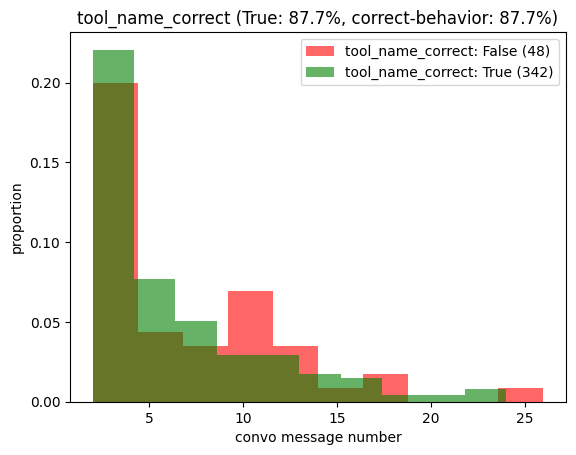

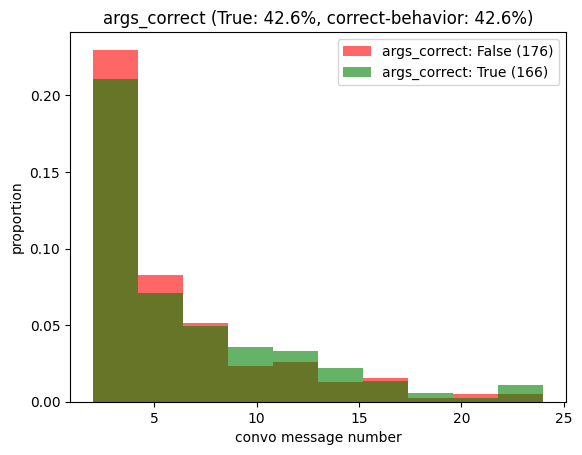

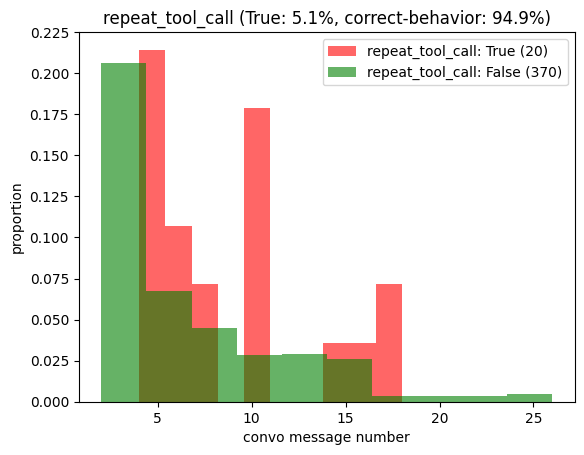

In [68]:
hist_turnnum_groupby_correct(results3, 'tool_name_correct', True)
hist_turnnum_groupby_correct(results3, 'args_correct', True)
hist_turnnum_groupby_correct(results3, 'repeat_tool_call', False)

In [34]:
results3.args_correct.mean()

np.float64(0.4853801169590643)

In [35]:
results3.repeat_tool_call.mean()

np.float64(0.05128205128205128)

## Test the test set:

In [55]:
testset_tested_turns = evaluation.eval_with_ref_dataset(test_examples, model_name)

Convo 0. Added 2 tested LLM turns (now collected: 2)
Convo 1. Added 3 tested LLM turns (now collected: 5)
Convo 2. Added 1 tested LLM turns (now collected: 6)
Convo 3. Added 4 tested LLM turns (now collected: 10)
Convo 4. Added 2 tested LLM turns (now collected: 12)
Convo 5. Added 4 tested LLM turns (now collected: 16)
Convo 6. Added 3 tested LLM turns (now collected: 19)
Convo 7. Added 2 tested LLM turns (now collected: 21)
Convo 8. Added 2 tested LLM turns (now collected: 23)
Convo 9. Added 2 tested LLM turns (now collected: 25)
Convo 10. Added 2 tested LLM turns (now collected: 27)
Convo 11. Added 3 tested LLM turns (now collected: 30)
Convo 12. Added 3 tested LLM turns (now collected: 33)
Convo 13. Added 4 tested LLM turns (now collected: 37)
Convo 14. Added 1 tested LLM turns (now collected: 38)
Convo 15. Added 1 tested LLM turns (now collected: 39)
Convo 16. Added 5 tested LLM turns (now collected: 44)
Convo 17. Added 2 tested LLM turns (now collected: 46)
Convo 18. Added 4 teste

In [56]:
test_eval_results_file = f'../data/eval/2t1-426.testset150.jsonl'
print(test_eval_results_file)
with open(test_eval_results_file, 'w', encoding='UTF-8') as f:
    for item in testset_tested_turns:
        line = json.dumps(item) + '\n'
        f.write(line)

../data/eval/2t1-426.testset150.jsonl


In [57]:
testres = pd.DataFrame(testset_tested_turns)
testres

,convo_id,convo_metadata,tested_turn_num,message_num,input_messages,reference_response,tested_response,expected_tool_name,response_tool_name,tool_name_correct,expected_tool_args,response_tool_args,args_correct,n_args_the_same,n_args_different,arg_differences,repeat_tool_call
0,0,"{'scenario': 'search_phrase', 'phrase_len': 3,...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""search_phrase"", ""arguments"": {""phras...","{""tool"": ""search_phrase"", ""arguments"": {""phras...",search_phrase,search_phrase,True,{'phrase': 'שמו יצחק והקמתי'},"{'phrase': 'שמו יצחק והקמתי', 'n_max_results': 1}",True,1.0,0.0,{},False
1,0,"{'scenario': 'search_phrase', 'phrase_len': 3,...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,{'text': '[Genesis 17:19]: ויאמר אלהים אבל שרה...,{'text': '<text to show the user>'},False,0.0,1.0,{'text': ('[Genesis 17:19]: ויאמר אלהים אבל שר...,False
2,1,"{'scenario': 'search_phrase', 'phrase_len': 1,...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""search_phrase"", ""arguments"": {""phras...","{""tool"": ""search_phrase"", ""arguments"": {""phras...",search_phrase,search_phrase,True,{'phrase': 'ילדו'},"{'phrase': 'ילדו', 'n_max_results': 10}",True,1.0,0.0,{},False
3,1,"{'scenario': 'search_phrase', 'phrase_len': 1,...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,{'text': 'O.K. I found 20 verses with the phra...,{'text': '[ילדו כ] (יעוש ק) ואת־יעלם ואת־קרח א...,False,0.0,1.0,{'text': ('O.K. I found 20 verses with the phr...,False
4,1,"{'scenario': 'search_phrase', 'phrase_len': 1,...",2,6,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,{'text': 'ויהי כי־החל האדם לרב על־פני האדמה וב...,{'text': 'Genesis 6 10 ויהי כי־החל האדם לרב ע...,False,0.0,1.0,{'text': ('ויהי כי־החל האדם לרב על־פני האדמה ו...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533,148,"{'scenario': 'lookup_verse_typo_version', 'var...",2,6,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...","{""tool"": ""lookup_verse"", ""arguments"": {""versio...",lookup_verse,lookup_verse,True,"{'version': 'en.koren', 'book': 'deuteronomy',...","{'version': 'en.koren', 'book': 'deuteronomy',...",True,4.0,0.0,{},False
534,148,"{'scenario': 'lookup_verse_typo_version', 'var...",3,8,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,{'text': 'So I spoke to you; and you would not...,{'text': 'So I spoke to you; and you would not...,True,1.0,0.0,{},False
535,149,"{'scenario': 'search_phrase', 'phrase_len': 1,...",0,2,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""search_phrase"", ""arguments"": {""phras...","{""tool"": ""search_phrase"", ""arguments"": {""phras...",search_phrase,search_phrase,True,{'phrase': 'אבן'},"{'phrase': 'אבן', 'n_max_results': 10}",True,1.0,0.0,{},False
536,149,"{'scenario': 'search_phrase', 'phrase_len': 1,...",1,4,"[{'role': 'system', 'content': 'You are a rese...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...","{""tool"": ""respond_to_user"", ""arguments"": {""tex...",respond_to_user,respond_to_user,True,{'text': 'O.K. I found 20 verses with the phra...,{'text': '<text to show the user>'},False,0.0,1.0,{'text': ('O.K. I found 20 verses with the phr...,False


In [80]:
testres[testres.convo_metadata.apply(lambda d:d['scenario'])=='sequence_of_user_requests']['convo_metadata'].values.tolist()

[{'scenario': 'sequence_of_user_requests',
  'sequence_length': 2,
  'sequence_of_scenarios': ['lookup_verse', 'search_phrase'],
  'metadata_sequence': [{'scenario': 'lookup_verse_ok',
    'variation': 17,
    'args': {'version': 'en.new.jps1917',
     'book': 'jeremiah',
     'chapter_num': 34,
     'verse_num': 14}},
   {'scenario': 'search_phrase',
    'phrase_len': 2,
    'phrase': 'ולקחת אשה',
    'n_results_found': 4,
    'n_results_show': 1,
    'show_how': 'ref',
    'instruct_when': True}],
  'tool_list_in_sys_prompt': ['search_phrase', 'lookup_verse']},
 {'scenario': 'sequence_of_user_requests',
  'sequence_length': 2,
  'sequence_of_scenarios': ['lookup_verse', 'search_phrase'],
  'metadata_sequence': [{'scenario': 'lookup_verse_ok',
    'variation': 17,
    'args': {'version': 'en.new.jps1917',
     'book': 'jeremiah',
     'chapter_num': 34,
     'verse_num': 14}},
   {'scenario': 'search_phrase',
    'phrase_len': 2,
    'phrase': 'ולקחת אשה',
    'n_results_found': 4,
  

In [83]:
def get_specific_scenario(convo_metadata):
    scenario = convo_metadata['scenario']
    if scenario == 'sequence_of_user_requests':
        scenario = '->'.join(convo_metadata['sequence_of_scenarios'])
    return scenario
display(testres.groupby(testres.convo_metadata.apply(lambda d:d['scenario'])).agg({'convo_id':'count', 'tool_name_correct':'mean', 'args_correct':'mean', 'repeat_tool_call': 'mean'}))
display(testres.groupby(testres.convo_metadata.apply(get_specific_scenario)).agg({'convo_id':'count', 'tool_name_correct':'mean', 'args_correct':'mean', 'repeat_tool_call': 'mean'}))

,convo_id,tool_name_correct,args_correct,repeat_tool_call
convo_metadata,,,,
chitchat,17,1.000000,0.0,0.000000
lookup_verse_ok,10,0.900000,0.555556,0.000000
lookup_verse_ok_then_another_version,41,0.878049,0.694444,0.000000
lookup_verse_typo_book,42,0.904762,0.394737,0.047619
lookup_verse_typo_version,56,0.821429,0.782609,0.035714
search_phrase,133,0.849624,0.318584,0.045113
sequence_of_user_requests,239,0.841004,0.482587,0.096234


,convo_id,tool_name_correct,args_correct,repeat_tool_call
convo_metadata,,,,
chitchat,17,1.000000,0.0,0.000000
chitchat->chitchat,2,0.500000,1.0,0.500000
chitchat->chitchat->search_phrase,8,0.875000,0.142857,0.125000
chitchat->lookup_verse,7,0.571429,0.5,0.000000
chitchat->search_phrase,7,0.857143,0.333333,0.142857
chitchat->search_phrase->lookup_verse,5,0.800000,0.0,0.000000
lookup_verse->chitchat,28,0.964286,0.555556,0.000000
lookup_verse->chitchat->lookup_verse,7,0.714286,0.2,0.000000
lookup_verse->lookup_verse,21,0.904762,0.526316,0.142857


In [58]:
pd.crosstab(testres.expected_tool_name, testres.response_tool_name)

response_tool_name,lookup_verse,respond_to_user,search_phrase
expected_tool_name,,,
lookup_verse,128,9,18
respond_to_user,20,264,10
search_phrase,21,0,68


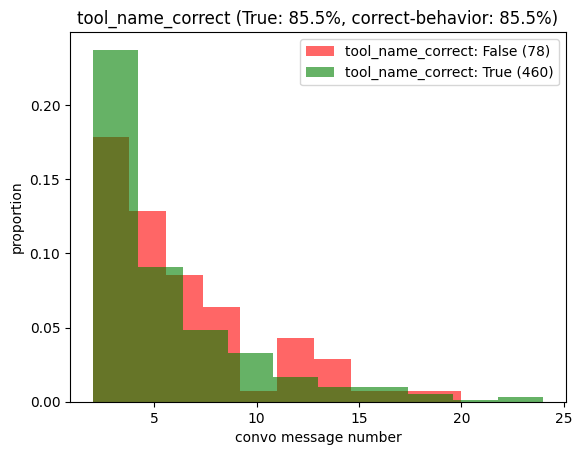

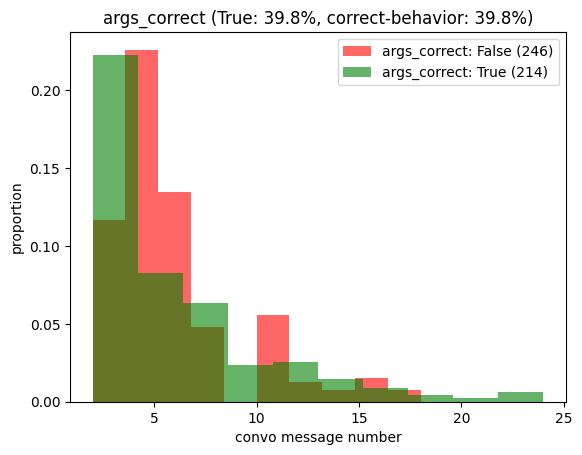

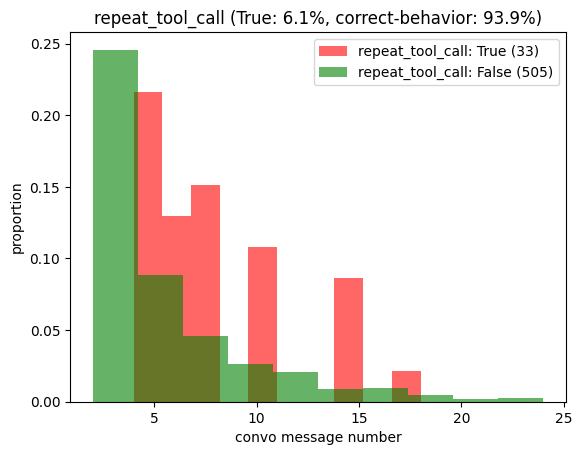

In [69]:
hist_turnnum_groupby_correct(testres, 'tool_name_correct', True)
hist_turnnum_groupby_correct(testres, 'args_correct', True)
hist_turnnum_groupby_correct(testres, 'repeat_tool_call', False)